# Pairs trading: Correlation-based selection (Static pairs selection & beta) — First iteration

Universe: crypto pairs, daily bars  
Train: 2022-01-01 → 2024-01-01  
Test: 2024-01-02 → 2026-05-22

Pipeline: Select pairs by training-period return correlation (threshold 0.8,
max 1 pair per coin) → static OLS hedge ratio → rolling 180-day z-score →
enter at |z|>2.5, exit at |z|<0.5 → normalize gross exposure to 1.

**Motivation**

- Two economically similar assets should move together. If their prices diverge, that gap is a candidate to bet on closing — long the laggard, short the leader, and profit as they reconverge.
- When a divergence opens we form a long–short *spread* trade and bet on it converging back toward its historical relationship.
- Crypto is younger, noisier and less efficient, making it promising ground for pairs trading — and a good stress test of whether the classic approach survives a higher-volatility regime.
- This notebook deliberately starts with the *simplest* selection rule — return correlation — as a **baseline**. Correlation is cheap and responsive, but it only measures co-movement of returns; it says nothing about whether two prices share a stable long-run relationship.

> **Why this is only a baseline.** Correlation says returns tend to move together day to day. It does *not* guarantee the spread between two prices is stationary or mean-reverting — two coins can be highly return-correlated and still drift apart for months. We keep this as the baseline, then test whether cointegration, which explicitly screens for a stationary mean-reverting combination, does better.

This is a simple approach which applies a static pair selection as well as a static beta hedge ratio calculation on the training data set to 2024-01-01 and then applies this to the remaining data.

**Key findings — correlation baseline (static beta)**

As per the below, we can see that the net Sharpe outperforms BTC over the full sample, but the strategy delivers lower annualised returns and slightly lower hit rates and drawdown duration (but a much lower maximum drawdown). The strategy has low correlation with a BTC HODL strategy. 

**Weaknesses/areas for improvement:** 

- **Static-beta bias.** The hedge ratio is fit by OLS on the 2022–24 training window and then frozen. Two problems follow. (1) *Overfitting:* because pairs are selected *and* β is fit on the same window, the in-sample spread is mechanically mean-zero and tight (OLS minimises in-sample residual variance), so the in-sample Sharpe (1.74) flatters the strategy relative to out-of-sample (0.80). (2) *Staleness:* if the true relationship drifts, the frozen β is mis-specified and the "spread" $\log P_i - \beta\log P_j - \alpha$ inherits a directional term.

- **Concentration / low breadth.** The 0.8 correlation threshold plus the one-pair-per-coin rule leaves only **10 pairs (20 coins)**. With gross exposure normalised to 1, that's a concentrated book: pair-specific risk dominates and a single diverging spread can drive the entire drawdown. By the fundamental law of active management ($\text{IR}\approx \text{IC}\times\sqrt{\text{breadth}}$).

- **Drawdown duration doubles gross → net.** Time underwater roughly doubles — from ~300 days gross to ~529 net (chart) — while max-DD *depth* barely moves. So costs are eating the *recovery*, not the *trough*: a drawdown only ends when returns reclaims its prior high.

*Performance by sample — net of 20 bps*

| Metric | In-sample | Out-of-sample | Full sample | BTC HODL |
|:--|--:|--:|--:|--:|
| Sharpe | 1.74 | 0.80 | 1.19 | 0.49 |
| Annualised return | 31.1% | 17.0% | 23.5% | 25.2% |
| Annualised vol | 17.9% | 21.2% | 19.8% | 51.6% |
| Hit rate | 55.3% | 52.8% | 53.8% | 49.6% |
| Max drawdown | −10.5% | −21.5% | −21.5% | −66.7% |
| Max DD duration (days) | 95 | 538 | 538 | 682 |

*Risk-adjusted vs BTC & portfolio (full sample, net)*

| Metric | Value |
|:--|--:|
| Pairs selected | 10 |
| Alpha t-stat | 2.52 |
| Information ratio | 0.99 |
| Beta to BTC | −0.02 |
| Daily turnover | 6.6% |
| Avg holding period | ~30 days |

In [20]:
# ____ Imports and data loading ____
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm

def read_crypto_data(interval):
    """
    Load cached price and volume pickles for a given timeframe
    interval:
        One of ["1d", "8h", "4h", "1h"] matching saved files.
    """
    path_px = Path(f"data_output/crypto_px_{interval}.pkl")
    path_vol = Path(f"data_output/crypto_vol_{interval}.pkl")
    if not path_px.exists() or not path_vol.exists():
        raise FileNotFoundError(f"Missing pickle files for interval {interval}")
    crypto_px = pd.read_pickle(path_px)
    crypto_vol = pd.read_pickle(path_vol)
    return crypto_px, crypto_vol

In [21]:
# ___ Functions for key stats/turnover/sharpe ____
# Annualisation helper
PERIODS_PER_YEAR = {"1d": 365, "8h": 365*3, "4h": 365*6, "1h": 365*24}

def compute_sharpe(rets,ppy=365):
    mean = rets.mean()*ppy # Crypto trades every day
    vol = rets.std()*np.sqrt(ppy)
    sharpe = mean / vol
    return sharpe

def drawdown(rets):
    cum = (1+rets).cumprod()
    return cum/cum.cummax()  - 1

def max_dd(rets):
    return drawdown(rets).min()

def max_dd_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return int(underwater.groupby(groups).cumsum().max())

def compute_keystats(rets, ppy=365):
    rets = rets.dropna()
    if len(rets) == 0:
        return pd.Series({'avg': np.nan, 'vol': np.nan, 'sharpe': np.nan,
                          'hit_rate': np.nan, 'max_dd': np.nan, 'max_dd_duration': np.nan,
        })
    avg = rets.mean() * ppy
    vol = rets.std() * np.sqrt(ppy)
    sharpe = avg / vol if vol > 0 else np.nan
    hit_rate = (rets > 0).sum() / (rets != 0).sum() if (rets != 0).any() else np.nan
    return pd.Series({'avg': avg, 'vol': vol, 'sharpe': sharpe,
                      'hit_rate': hit_rate, 'max_dd':max_dd(rets),'max_dd_duration':max_dd_duration(rets)})

def compute_turnover(port):
    to = (port.fillna(0)-port.shift().fillna(0)).abs().sum(1)
    return to

## Pairs Selection

Pairs are selected **once, on the training window only** (2022-01-01 → 2024-01-01) and then held fixed for the whole backtest. This keeps the baseline simple and avoids look-ahead — nothing in the test period influences which pairs we trade.

- **Correlation measure:** compute the correlation matrix of *log returns* (the first difference of log prices) across all eligible coins over the training window. Eligible coins are those with ≥ 90% data coverage in training.
- **Selection rule:** keep every pair whose return correlation exceeds 0.8, ranked high to low, accepting a pair only if neither coin is already used — so each coin appears in at most one pair. The result is a set of non-overlapping, highly co-moving pairs.

> **Fault to keep in mind.** Selecting on *return* correlation is a statement about short-horizon co-movement, not about the *level* relationship between prices. A pair can show 0.9 return correlation while its price ratio wanders persistently — nothing here forces the spread back to a mean. Cointegration tackles this head-on by testing whether a linear combination of the log *price levels* is stationary.

In [18]:
# ____ Pair selection by return correlation (selection step) ____
def sel_corr_pairs(train_px, corr_thresh=0.8, unique_coins=True):
    log_ret = np.log(train_px.replace(0, np.nan)).diff()
    corr = log_ret.corr()

    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            c = corr.iloc[i, j]
            if pd.notna(c) and c > corr_thresh:
                pairs.append({'coin1': cols[i], 'coin2': cols[j], 'corr': c})
    pairs_df = pd.DataFrame(pairs).sort_values('corr', ascending=False).reset_index(drop=True)

    # Max 1 pair per coin 
    if unique_coins and not pairs_df.empty:
        used = set()
        keep = []
        for _, row in pairs_df.iterrows():
            if row.coin1 not in used and row.coin2 not in used:
                keep.append(row)
                used.update([row.coin1, row.coin2])
        pairs_df = pd.DataFrame(keep).reset_index(drop=True)

    return pairs_df

### Static hedge ratio (OLS)

Before we can build a spread we need a *hedge ratio* — how many units of coin $j$ to hold against one unit of coin $i$. For each selected pair we estimate it with a single ordinary-least-squares regression of the log prices, on the **training window only**:

$$\log P_{i,t} = \alpha + \beta\,\log P_{j,t} + \varepsilon_t.$$

OLS chooses $\alpha$ and $\beta$ to minimise the in-sample sum of squared residuals $\sum_t \varepsilon_t^2$. The two fitted coefficients are:

- **$\beta$ (slope) — the hedge ratio.** Because we work in log prices, $\beta$ is an elasticity: a 1% move in $P_j$ is associated on average with a $\beta$% move in $P_i$. It tells us how much of coin $j$ to short (or long) against coin $i$ so that the combined position is, in principle, market-neutral.
- **$\alpha$ (intercept) — the level offset.** It centres the relationship so the residual has mean ≈ 0 over the training sample.

The quantity the strategy actually trades is the **residual / spread**,

$$\varepsilon_t = \log P_{i,t} - \beta\,\log P_{j,t} - \alpha,$$

which feeds straight into the z-score in the next step. Crucially, $\alpha$ and $\beta$ are estimated once and **frozen** — the same values are applied across the entire backtest, so no test-period information leaks into the hedge ratio.

In [19]:
# ____ Static OLS hedge ratio: log(P_i) = alpha + beta*log(P_j) on TRAIN only.
# Adds 'alpha'/'beta' columns
def fit_beta(pairs_df, train_px):
    alphas, betas = [], []
    for _, row in pairs_df.iterrows():
        asset_i, asset_j = row['coin1'], row['coin2']
        y = np.log(train_px[asset_i].replace(0, np.nan)).dropna()
        x = np.log(train_px[asset_j].replace(0, np.nan)).dropna()
        df = pd.concat([y, x], axis=1).dropna()
        df.columns = ["y", "x"]
        model = sm.OLS(df["y"], sm.add_constant(df["x"])).fit()
        alphas.append(model.params["const"])
        betas.append(model.params["x"])
    pairs_df = pairs_df.copy()
    pairs_df["alpha"] = alphas
    pairs_df["beta"] = betas
    return pairs_df

## Trading Strategy

### 1. Signal generation

- **Hedge ratio (static):** for each pair $(i,j)$ we fit one OLS regression on the **training data only**,
$$\log P_{i,t} = \alpha + \beta\,\log P_{j,t} + \varepsilon_t,$$
and freeze the fitted $\alpha$ and $\beta$ for the entire backtest — hence "static beta."
- **Spread / residual:** using those fixed coefficients,
$$s_t = \log P_{i,t} - \beta\,\log P_{j,t} - \alpha.$$
- **Z-score:** standardise the spread on a rolling 180-day window,
$$z_t = \frac{s_t - \overline{s}^{\,(180)}_t}{\sigma^{\,(180)}_{s,t}},$$
where $\overline{s}^{\,(180)}$ and $\sigma^{\,(180)}_s$ are the 180-day rolling mean and standard deviation of the spread (minimum 90 observations).

> **Fault to keep in mind.** The hedge ratio is estimated once and frozen. If the true relationship drifts over the two-year test period — common in crypto — the spread becomes mis-centred, the rolling z-score reverts toward a mean that no longer reflects equilibrium, and signals decay out-of-sample. Two follow-ups address this: cointegration screens for pairs whose spread is statistically stationary to begin with, and rolling-beta lets $\beta$ adapt over time.

### 2. Portfolio construction

- **Entry:**
  - If $z_t > 2.5$: short coin $i$ (weight $-1$), long $\beta$ units of coin $j$ (weight $+\beta$) — betting the stretched spread narrows.
  - If $z_t < -2.5$: long coin $i$ (weight $+1$), short $\beta$ units of coin $j$ (weight $-\beta$).
- **Exit:** flatten the pair once $|z_t| < 0.5$; between entry and exit the position is held (forward-filled).
- **Sizing:** each day raw weights are normalised so gross exposure $\sum|w| = 1$ (or 0 when fully flat), so the book is always fully invested or in cash, with risk shared across active pairs.

In [22]:
# ___ Signal construction (spread → z-score) ___
def build_signals(px, pairs_df, window = 180):
    key_params = {}
    for _,row in pairs_df.iterrows():
        asset_i = row['coin1']
        asset_j = row['coin2']
        alpha = row['alpha']
        beta = row['beta']
        pair = (asset_i, asset_j)

        log_i = np.log(px[asset_i].replace(0, np.nan).ffill())
        log_j = np.log(px[asset_j].replace(0, np.nan).ffill())

        resid = log_i - (beta * log_j) - alpha
        resid_mean = resid.rolling(window=window, min_periods=window//2).mean()
        resid_std = resid.rolling(window=window, min_periods=window//2).std()
        z_score = (resid - resid_mean) / resid_std
        key_params[(pair, 'beta')] = pd.Series(beta, index=px.index)
        key_params[(pair, 'alpha')] = pd.Series(alpha, index=px.index)
        key_params[(pair, 'resid')] = resid
        key_params[(pair, 'z_score')] = z_score
    return pd.DataFrame(key_params)

In [23]:
# ____ Position sizing (z-score → weights) ____
def build_weights(key_params, pairs_df, z_entry = 2.5, z_exit = 0.5):
    """ Convert the pair-level z-scores into per-coin portfolio weights.
    Then normalise so absolute sum of weights equal to 1"""
    pairs = list(zip(pairs_df['coin1'], pairs_df['coin2']))
    coins = sorted({c for pair in pairs for c in pair})
    raw = pd.DataFrame(index=key_params.index, columns=coins, dtype=float)
    for pair in pairs:
        asset_i, asset_j = pair
        z = key_params[(pair, 'z_score')]
        beta = key_params[(pair, 'beta')]

        # Entries
        raw.loc[z > z_entry,  asset_i] = -1
        raw.loc[z > z_entry,  asset_j] = beta
        raw.loc[z < -z_entry, asset_i] = 1
        raw.loc[z < -z_entry, asset_j] = -beta
        # Exits override entries when |z| is small
        flat = z.abs() < z_exit
        raw.loc[flat, asset_i] = 0
        raw.loc[flat, asset_j] = 0

    # Hold previous position between entry and exit thresholds
    raw = raw.ffill()
    # Normalise per bar so |weights|.sum = 1 (or 0 if all flat)
    pos = raw.divide(raw.abs().sum(axis=1),axis=0).fillna(0)

    return pos

In [24]:
# ___ Backtest formula ____
def backtest(px, pos):
    simple_ret = px.pct_change(fill_method = None)
    cols = [c for c in pos.columns if c in simple_ret.columns]
    port_ret = (pos[cols].shift(1) * simple_ret[cols]).sum(axis=1) # Avoid lookahead bias
    return port_ret

In [25]:
# ____ Main run and stats for different sample periods ____
def run_strategy(px, pairs_df,  window=180, z_entry=2.5, z_exit=0.5):
    """
    Run the full pipeline on a price series and return strategy returns.
    """
    signals = build_signals(px, pairs_df, window=window)
    weights = build_weights(signals, pairs_df,
                            z_entry=z_entry, z_exit=z_exit)
    port_ret = backtest(px, weights)
    return port_ret, weights, signals

def split_stats(port_ret, split_date, ppy=365):
    """
    Compute key stats for in-sample, out-of-sample, and full-sample periods.
    split_date: first date of the out-of-sample period.
    """
    in_sample = port_ret.loc[:split_date].iloc[:-1]   # exclude split_date itself
    out_sample = port_ret.loc[split_date:]
    full_sample = port_ret

    stats = pd.DataFrame({
        'in_sample': compute_keystats(in_sample, ppy=ppy),
        'out_sample': compute_keystats(out_sample, ppy=ppy),
        'full_sample': compute_keystats(full_sample, ppy=ppy),
    })
    return stats

## Performance Evaluation

We run one configuration ($|z|>2.5$ entry, $|z|<0.5$ exit, 180-day z-window) and report — for in-sample, out-of-sample and full-sample periods, against a BTC buy-and-hold benchmark:

- **Annualised return** and **annualised volatility** (365 periods/year — crypto trades every day).
- **Sharpe ratio** — risk-adjusted return.
- **Hit rate** — share of non-flat days that are positive.
- **Max drawdown** and **drawdown duration** — depth and length of the worst peak-to-trough.
- **Turnover** and **implied holding period** — average daily fraction of the book traded, and $\approx 2/\text{turnover}$ days per round trip.
- **Alpha, beta and information ratio vs BTC** (HAC standard errors) — to confirm returns aren't just disguised BTC exposure.

**Costs.** Crypto commissions run ~7 bps. Slippage is trader- and size-dependent; we assume a further 13 bps, for ~20 bps all-in on market orders. We report two cost models: a flat 20 bps on all turnover, and, at the end of the notebook, a **liquidity-aware** model charging 7 bps on coins whose 30-day rolling dollar volume exceeds \$10m and 20 bps otherwise.

After correlation filter: 10 pairs

Stats by sample (gross of fees):
                 in_sample  out_sample  full_sample    btc_hodl
avg               0.365463    0.212818     0.282645    0.251746
vol               0.180418    0.213035     0.198759    0.515834
sharpe            2.025645    0.998984     1.422049    0.488037
hit_rate          0.566225    0.536471     0.548831    0.496222
max_dd           -0.105469   -0.207735    -0.207735   -0.667306
max_dd_duration  90.000000  303.000000   303.000000  682.000000


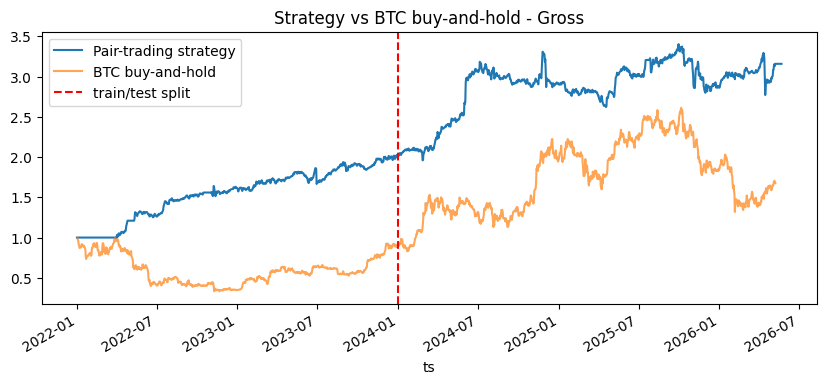

In [26]:
split_date = "2024-01-02"
split_ts = pd.to_datetime(split_date)
crypto_px, crypto_vol = read_crypto_data("1d")
train_px = crypto_px.loc[:"2024-01-01"].copy()

# Universe: require >= 90% coverage over the training window
coverage = train_px.notna().mean()
eligible = coverage[coverage >= 0.90].index
crypto_px = crypto_px[eligible]
crypto_vol = crypto_vol[eligible]
train_px = train_px[eligible]

# 1. Correlation pair selection on training data - 80% filter
pairs_df = sel_corr_pairs(train_px, corr_thresh=0.8)
print(f"After correlation filter: {len(pairs_df)} pairs")

# 2. Static OLS hedge ratio on training data only
pairs_df = fit_beta(pairs_df, train_px)

# 3. Run strategy on FULL price series (training betas applied throughout)
port_ret, weights, signals = run_strategy(
    crypto_px, pairs_df, window=180, z_entry=2.5, z_exit=0.5
)

# 4. Gross stats by period + BTC benchmark
stats = split_stats(port_ret, split_date=split_date, ppy=365)
btc_ret = crypto_px['BTC/USDT'].pct_change(fill_method=None).dropna()
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined = pd.concat([stats, btc_full], axis=1)
print("\nStats by sample (gross of fees):")
print(combined)

# 5. Equity curve vs BTC
equity = (1 + port_ret).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity.plot(figsize=(10, 4), label='Pair-trading strategy')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(split_ts, color='red', linestyle='--', label='train/test split')
ax.set_title("Strategy vs BTC buy-and-hold - Gross")
ax.legend()
plt.show()

Turnover is 0.06584262520421066
Corresponding holding period is 30.37545957192635

Stats by sample (net of 20bps):
                 in_sample  out_sample  full_sample    btc_hodl
avg               0.311269    0.169921     0.234580    0.251746
vol               0.179155    0.212012     0.197635    0.515834
sharpe            1.737428    0.801466     1.186935    0.488037
hit_rate          0.552632    0.527615     0.538040    0.496222
max_dd           -0.105469   -0.215200    -0.215200   -0.667306
max_dd_duration  95.000000  538.000000   538.000000  682.000000


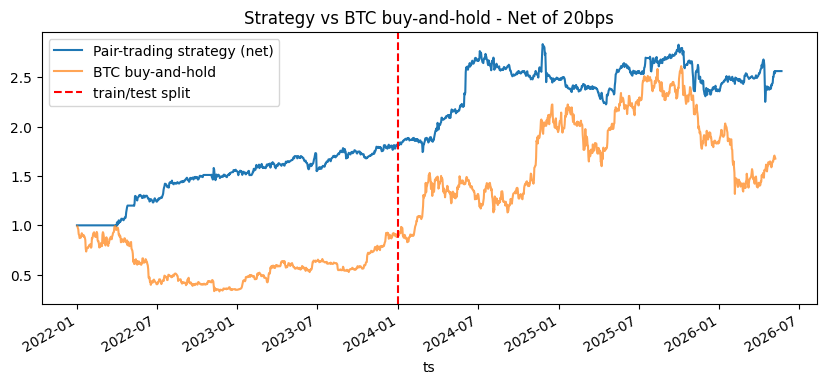

In [10]:
# ____ Net returns (flat 20bps) + stats ____
tcost_bps = 20  # 20 bps for market orders (commissions + slippage)
to = compute_turnover(weights)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(to * tcost_bps * 1e-4, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")
# ---------- Stats ----------
stats_net = split_stats(port_ret_net, split_date=split_date, ppy=365)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nStats by sample (net of {tcost_bps}bps):")
print(combined_net)

equity_net = (1 + port_ret_net).cumprod()
btc_equity = (1 + btc_ret).cumprod()
ax = equity_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_equity.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(split_ts, color='red', linestyle='--', label='train/test split')
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of {tcost_bps}bps")
ax.legend()
plt.show()

In [11]:
# ____ BM-adjusted performance vs BTC ___
def alpha_beta_block(strat_ret, btc_ret, label, ppy=365, roll_window=365, hac_lags=5):
    """Compute beta, alpha, alpha t-stat, IR"""
    df = pd.concat([strat_ret.rename('strat'), btc_ret.rename('btc')], axis=1).dropna()

    # Rolling PIT beta + residuals
    corr = df['strat'].rolling(roll_window).corr(df['btc'])
    vol_s = df['strat'].rolling(roll_window).std()
    vol_b = df['btc'].rolling(roll_window).std()
    beta_roll = corr * vol_s / vol_b
    resid = df['strat'] - beta_roll * df['btc']
    ir = resid.mean() / resid.std() * np.sqrt(ppy) if resid.std() > 0 else np.nan

    # Full-sample OLS for alpha + t-stat
    X = sm.add_constant(df['btc'])
    model = sm.OLS(df['strat'], X).fit(cov_type='HAC', cov_kwds={'maxlags': hac_lags})
    alpha_ann   = model.params['const'] * ppy
    beta_full   = model.params['btc']
    alpha_tstat = model.tvalues['const']
    stats = pd.Series({'beta_OLM': beta_full, 'alpha_ann':   alpha_ann, 'alpha_tstat': alpha_tstat,
        'ir':ir,}, name=label)
    return stats, resid

# Apply to gross and net
gross_ab, gross_resid = alpha_beta_block(port_ret, btc_ret, 'gross')
net_ab, net_resid   = alpha_beta_block(port_ret_net, btc_ret, 'net')

ab_table = pd.concat([gross_ab, net_ab], axis=1)
print("\nAlpha/Beta/IR vs BTC:")
print(ab_table)

corr_df = pd.concat([
    net_resid.rename('resid_net'),
    btc_ret.rename('btc'),
], axis=1).dropna()
print("Correlation of resids with BTC matrix:")
print(corr_df.corr().round(3))


Alpha/Beta/IR vs BTC:
                gross       net
beta_OLM    -0.018894 -0.018133
alpha_ann    0.289181  0.240622
alpha_tstat  2.999990  2.518108
ir           1.231905  0.988024
Correlation of resids with BTC matrix:
           resid_net    btc
resid_net      1.000  0.035
btc            0.035  1.000


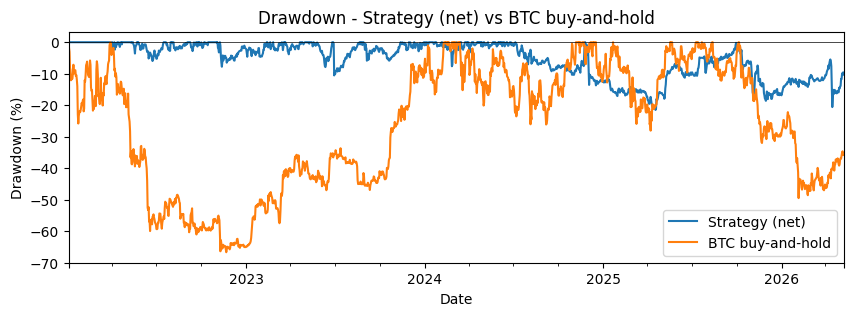

Max drawdown - Strategy (net):   -21.52%
Max drawdown - BTC buy-and-hold: -66.73%


In [12]:
# ___ Drawdown: Strategy (net) vs BTC HODL ___
comb_ret = pd.concat([
    port_ret_net.rename('strat_ret'),
    btc_ret.rename('buy_and_hold_btc'),
], axis=1).dropna()

dd = drawdown(comb_ret) * 100

plt.figure(figsize=(10, 3))
dd.plot(ax=plt.gca())
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Drawdown - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()
print(f"Max drawdown - Strategy (net):   {dd['strat_ret'].min():.2f}%")
print(f"Max drawdown - BTC buy-and-hold: {dd['buy_and_hold_btc'].min():.2f}%")

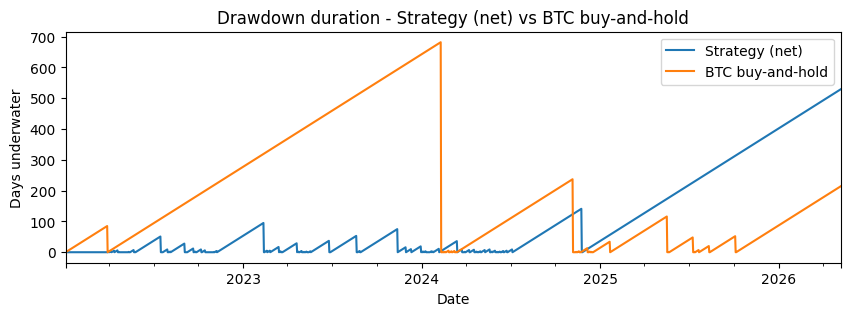

Max drawdown duration - Strategy (net):   529 days
Max drawdown duration - BTC buy-and-hold: 682 days


In [13]:
# ___ Drawdown duration: Strategy (net) vs BTC HODL ___
def drawdown_duration(rets):
    dd = drawdown(rets)
    underwater = dd < 0
    groups = (~underwater).cumsum()
    return underwater.groupby(groups).cumsum()

ddd = comb_ret.apply(drawdown_duration)

plt.figure(figsize=(10, 3))
ddd.plot(ax=plt.gca())
plt.title('Drawdown duration - Strategy (net) vs BTC buy-and-hold')
plt.xlabel('Date')
plt.ylabel('Days underwater')
plt.legend(['Strategy (net)', 'BTC buy-and-hold'])
plt.show()

print(f"Max drawdown duration - Strategy (net):   {int(ddd['strat_ret'].max())} days")
print(f"Max drawdown duration - BTC buy-and-hold: {int(ddd['buy_and_hold_btc'].max())} days")

In [14]:
# Gross exposure should be ~1.0 every day (or 0 when fully flat)
gross = weights.abs().sum(axis=1)
print("\nGross exposure stats:")
print(gross.describe())
print(f"\nDays with gross == 0 (fully flat): {(gross == 0).sum()}")
print(f"Days with gross ~= 1: {((gross > 0.99) & (gross < 1.01)).sum()}")
print(f"\nGross exposure around split:")
print(gross.loc[split_ts - pd.Timedelta(days=2):split_ts + pd.Timedelta(days=2)])


Gross exposure stats:
count    1598.000000
mean        0.916145
std         0.277257
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64

Days with gross == 0 (fully flat): 134
Days with gross ~= 1: 1464

Gross exposure around split:
ts
2023-12-31    1.0
2024-01-01    1.0
2024-01-02    1.0
2024-01-03    1.0
2024-01-04    1.0
dtype: float64


In [15]:
# ____ Net returns — liquidity-aware cost model ___
def compute_liquidity_aware_costs(weights, crypto_px, crypto_vol,
                                   high_liquidity_threshold_usd=10_000_000,
                                   slow_bps=7, fast_bps=20,
                                   rolling_days=30):
    w = weights.fillna(0)
    pos_change = (w - w.shift().fillna(0)).abs()
    dollar_vol = crypto_px * crypto_vol
    rolling_dvol = dollar_vol.rolling(rolling_days, min_periods=5).mean()
    common_cols = [c for c in pos_change.columns if c in rolling_dvol.columns]
    pos_change = pos_change[common_cols]
    rolling_dvol = rolling_dvol[common_cols].reindex(pos_change.index)
    bps = pd.DataFrame(
        np.where(rolling_dvol >= high_liquidity_threshold_usd, slow_bps, fast_bps),
        index=pos_change.index, columns=pos_change.columns,
    )
    daily_costs = (pos_change * bps * 1e-4).sum(axis=1).fillna(0)
    return daily_costs

Turnover is 0.06584262520421066
Corresponding holding period is 30.37545957192635

Stats by sample (net of fees):
                 in_sample  out_sample  full_sample    btc_hodl
avg               0.328450    0.180794     0.248339    0.251746
vol               0.179620    0.212310     0.198004    0.515834
sharpe            1.828583    0.851559     1.254212    0.488037
hit_rate          0.557566    0.527615     0.540096    0.496222
max_dd           -0.105469   -0.211910    -0.211910   -0.667306
max_dd_duration  95.000000  308.000000   308.000000  682.000000


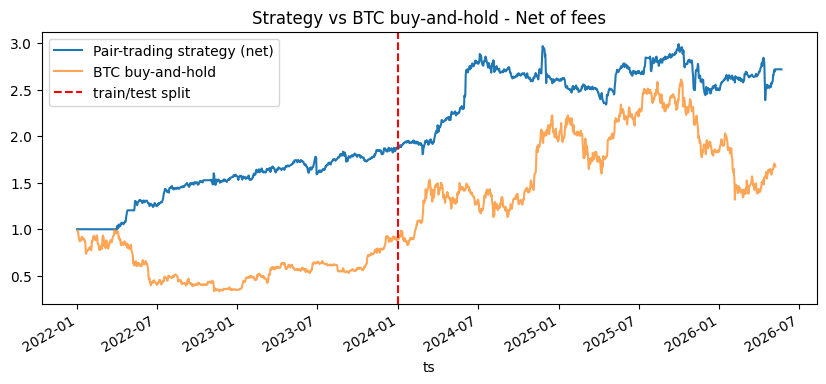

In [16]:
# ____ Net returns (with liquidity aware) + stats ____
daily_costs = compute_liquidity_aware_costs(weights, crypto_px, crypto_vol)
to = compute_turnover(weights)
turnover = to.mean()
holding_period = 2/turnover
port_ret_net = port_ret.subtract(daily_costs, fill_value=0)
print(f"Turnover is {turnover}")
print(f"Corresponding holding period is {holding_period}")

# ---------- Stats ----------
stats_net = split_stats(port_ret_net, split_date=split_date, ppy=365)
btc_full = compute_keystats(btc_ret, ppy=365).rename('btc_hodl')
combined_net = pd.concat([stats_net, btc_full], axis=1)
print(f"\nStats by sample (net of fees):")
print(combined_net)

perf_net = (1 + port_ret_net).cumprod()
btc_perf = (1 + btc_ret).cumprod()
ax = perf_net.plot(figsize=(10, 4), label='Pair-trading strategy (net)')
btc_perf.plot(ax=ax, label='BTC buy-and-hold', alpha=0.7)
ax.axvline(pd.to_datetime(split_date), color='red', linestyle='--', label='train/test split')
ax.set_title(f"Strategy vs BTC buy-and-hold - Net of fees")
ax.legend()
plt.show()